In [16]:
import modules.pipeline
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import cv2
import easyocr

def show(img, title="Immagine"):
    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    # plt.axis('off')
    plt.show()

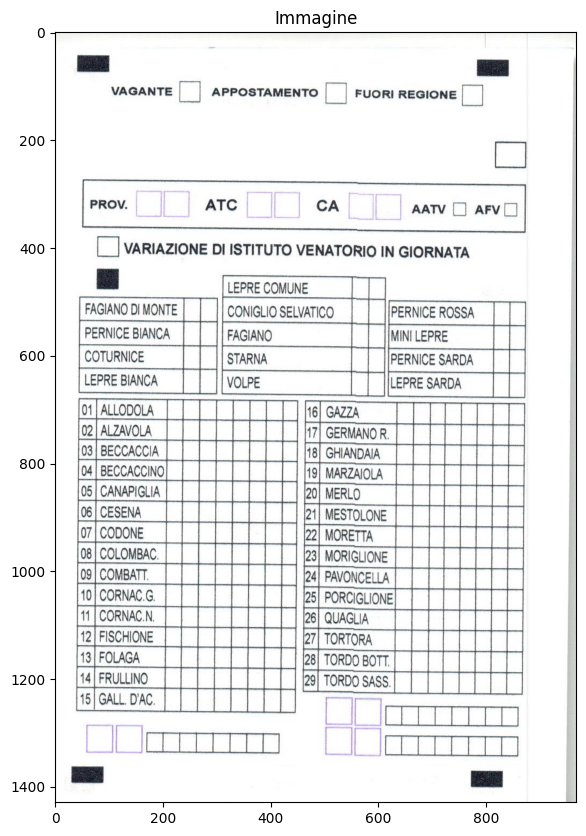

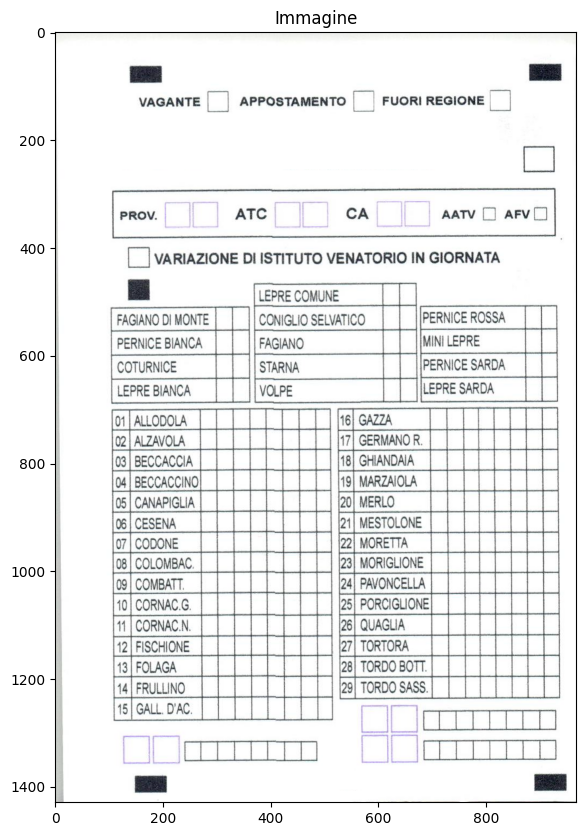

In [17]:
base_dispari = modules.pipeline.Pipeline('VI20240_20251215_142059/0027_.jpg')
empty_dispari = base_dispari.run()
# show(out)
empty_dispari[140:246, 38:778] = 255
empty_dispari[1362:1392, 408:450] = 255
show(empty_dispari)
base_pari = modules.pipeline.Pipeline('VI20240_20251215_142059/0028_.jpg')
empty_pari = base_pari.run()
# show(out)
empty_pari[150:255, 38:820] = 255
empty_pari[1370:1406, 520:570] = 255
show(empty_pari)


In [18]:
NO_NUM_CX = (480, 770)

FORM_LAYOUT = {
    # ── Header — tipo di caccia (cy ≈ 126-129) ─────────────────────────────────
    'header': {
        302: 'vagante',
        572: 'appostamento',
        825: 'fuori_regione',
    },

    # ── Compilato — casella "foglio con segni da leggere" (cy ≈ 236) ────────────
    # A destra della data; barrare = questo foglio contiene giornate compilate
    'compilato': {
        897: 'compilato',
    },

    # ── Istituto venatorio (cy ≈ 337-341) ──────────────────────────────────────
    'istituto': {
        227: 'PROV',   # 2 caselle OCR — sigla provincia italiana (es. VI, VE)
        431: 'ATC',    # 2 caselle OCR — codice numerico
        620: 'CA',     # 2 caselle OCR — codice alfanumerico
        805: 'AATV',   # 1 casella flag
        900: 'AFV',    # 1 casella flag
    },

    # ── Variazione di istituto venatorio in giornata (cy ≈ 398-418) ────────────
    # Casella a sinistra dell'etichetta "VARIAZIONE DI ISTITUTO VENATORIO IN GIORNATA"
    'variazione': {
        156: 'variazione',
    },

    # ── Specie non numerate — colonna sinistra (cx < 480, cy ≥ 460) ─────────────
    'no_num_sx': {
        511: ('', "FAGIANO DI MONTE"),
        554: ('', 'PERNICE BIANCA'),
        598: ('', 'COTURNICE'),
        643: ('', 'LEPRE BIANCA'),
    },

    # ── Specie non numerate — colonna centrale (480 ≤ cx < 770, cy ≥ 460) ───────
    'no_num_centro': {
        467: ('', 'LEPRE COMUNE'),
        508: ('', 'CONIGLIO SELVATICO'),
        553: ('', 'FAGIANO'),
        597: ('', 'STARNA'),
        643: ('', 'VOLPE'),
    },

    # ── Specie non numerate — colonna destra (cx ≥ 770, cy ≥ 460) ───────────────
    'no_num_dx': {
        508: ('', 'PERNICE ROSSA'),
        551: ('', 'MINI LEPRE'),
        596: ('', 'PERNICE SARDA'),
        641: ('', 'LEPRE SARDA'),
    },

    # ── Griglia sinistra numerata (cx < 480, cy ≥ 700) ──────────────────────────
    'sx': {
         710: ('01', 'ALLODOLA'),
         747: ('02', 'ALZAVOLA'),
         785: ('03', 'BECCACCIA'),
         823: ('04', 'BECCACCINO'),
         862: ('05', 'CANAPIGLIA'),
         900: ('06', 'CESENA'),
         938: ('07', 'CODONE'),
         976: ('08', 'COLOMBACCIO'),
        1014: ('09', 'COMBATTENTE'),
        1054: ('10', 'CORNACCHIA G.'),
        1094: ('11', 'CORNACCHIA N.'),
        1131: ('12', 'FISCHIONE'),
        1169: ('13', 'FOLAGA'),
        1208: ('14', 'FRULLINO'),
        1240: ('15', "GALL. D'ACQUA"),
    },

    # ── Griglia destra numerata (cx ≥ 480, cy ≥ 700) ───────────────────────────
    'dx': {
         713: ('16', 'GAZZA'),
         752: ('17', 'GERMANO R.'),
         789: ('18', 'GHIANDAIA'),
         827: ('19', 'MARZAIOLA'),
         866: ('20', 'MERLO'),
         904: ('21', 'MESTOLONE'),
         942: ('22', 'MORETTA'),
         980: ('23', 'MORIGLIONE'),
        1019: ('24', 'PAVONCELLA'),
        1057: ('25', 'PORCIGLIONE'),
        1096: ('26', 'QUAGLIA'),
        1134: ('27', 'TORTORA'),
        1173: ('28', 'TORDO BOTT.'),
        1212: ('29', 'TORDO SASS.'),
    },
}

OVERFLOW_Y_MIN = 1248


def _nearest(d, val):
    return d[min(d, key=lambda k: abs(k - val))]


def annotate_box(box):
    x, y, w, h = box['bbox']
    cx, cy = x + w / 2, y + h / 2
    nb = dict(box)

    if cy < 160:
        flag = _nearest(FORM_LAYOUT['header'], cx)
        nb['label_type'] = 'header'
        nb['label']      = flag
        nb['num']        = ''
        nb['name']       = flag

    elif cy < 260:
        flag = _nearest(FORM_LAYOUT['compilato'], cx)
        nb['label_type'] = 'compilato'
        nb['label']      = flag
        nb['num']        = ''
        nb['name']       = flag

    elif cy < 370:
        field = _nearest(FORM_LAYOUT['istituto'], cx)
        nb['label_type'] = 'istituto'
        nb['label']      = field
        nb['num']        = ''
        nb['name']       = field

    elif cy < 460:
        flag = _nearest(FORM_LAYOUT['variazione'], cx)
        nb['label_type'] = 'variazione'
        nb['label']      = flag
        nb['num']        = ''
        nb['name']       = flag

    elif cy < 700:
        cx_lo, cx_hi = NO_NUM_CX
        if cx < cx_lo:
            section = 'no_num_sx'
        elif cx < cx_hi:
            section = 'no_num_centro'
        else:
            section = 'no_num_dx'
        num, name = _nearest(FORM_LAYOUT[section], cy)
        nb['label_type'] = 'specie'
        nb['num']        = num
        nb['name']       = name
        nb['label']      = name

    elif cy < OVERFLOW_Y_MIN:
        section = 'sx' if cx < 480 else 'dx'
        num, name = _nearest(FORM_LAYOUT[section], cy)
        nb['label_type'] = 'specie'
        nb['num']        = num
        nb['name']       = name
        nb['label']      = f"{num}. {name}" if num else name

    else:
        # Caselle più grandi (w≥40): contengono il numero specie scritto a mano (OCR)
        # Caselle piccole (w<40): caselle dei segni di abbattimento
        nb['label_type']    = 'overflow'
        nb['label']         = 'overflow'
        nb['overflow_type'] = 'num' if w >= 40 else 'mark'
        nb['num']           = ''
        nb['name']          = ''

    return nb


Using CPU. Note: This module is much faster with a GPU.


Riquadri annotati: dispari=301  pari=301

── 0049  OTTOBRE 2024 DOMENICA 13
  vagante: ✗ appostamento: ✓ fuori_regione: ✗
  ✓ 28. TORDO BOTT. — 8 abbattimenti
  ✓ 29. TORDO SASS. — 1 abbattimento
  ✓ overflow specie 4 — 4 abbattimenti
  ✓ overflow specie 2 — 8 abbattimenti


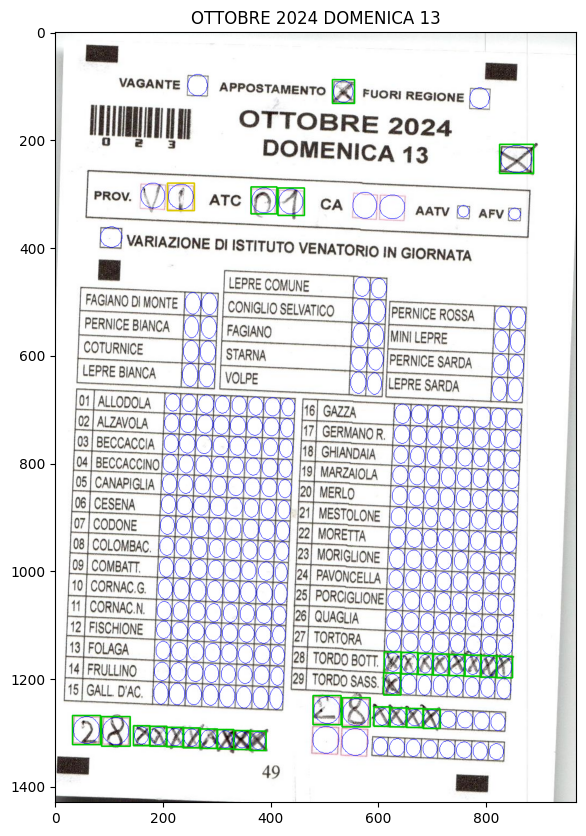

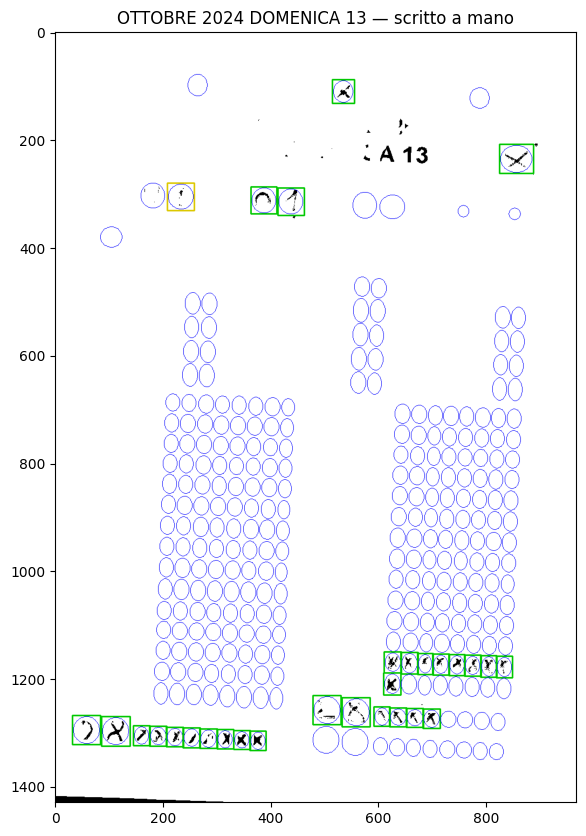

In [19]:
from modules.marks import detect_form_boxes, check_box_marks, draw_box_marks, find_corner_marks, transform_boxes
from collections import defaultdict

# ── 1. Template: riquadri annotati e marcatori angolari ───────────────────────
empty_raw_dispari = modules.pipeline.Pipeline('VI20240_20251215_142059/0027_.jpg').run()
empty_raw_pari    = modules.pipeline.Pipeline('VI20240_20251215_142059/0028_.jpg').run()

DATE_ZONE       = [(200, 165, 800, 310)]
corners_dispari = find_corner_marks(empty_raw_dispari)
corners_pari    = find_corner_marks(empty_raw_pari)

boxes_dispari = [annotate_box(b) for b in detect_form_boxes(empty_raw_dispari, threshold=220, exclude_regions=DATE_ZONE)]
boxes_pari    = [annotate_box(b) for b in detect_form_boxes(empty_raw_pari,    threshold=220, exclude_regions=DATE_ZONE)]

print(f"Riquadri annotati: dispari={len(boxes_dispari)}  pari={len(boxes_pari)}")

DATE_Y0, DATE_Y1, DATE_X0, DATE_X1 = 140, 280, 80, 880
INK_THRESHOLD = 0.04
UNCERTAIN_THR = 0.015

easyocr_reader = easyocr.Reader(['it'], gpu=False)

OVERFLOW_COL_SPLIT = 450

# Range HSV per il viola dei bordi stampati — H 118-145, V>150 esclude inchiostro scuro
PURPLE_HSV_LO = np.array([118, 12, 150])  # viola chiaro: H picco 125-135, V alto esclude inchiostro scuro
PURPLE_HSV_HI = np.array([145, 90, 255])


def subtract_template(filled, empty_raw, t_corners, form_corners):
    """Ritorna un'immagine grayscale con solo l'inchiostro scritto a mano."""
    src = np.float32([t_corners['tl'], t_corners['tr'], t_corners['br'], t_corners['bl']])
    dst = np.float32([form_corners['tl'], form_corners['tr'], form_corners['br'], form_corners['bl']])
    H, _ = cv2.findHomography(src, dst)
    h_f, w_f = filled.shape[:2]
    warped = cv2.warpPerspective(
        cv2.cvtColor(empty_raw, cv2.COLOR_RGB2GRAY), H, (w_f, h_f),
        flags=cv2.INTER_LINEAR, borderValue=255)
    form_gray = cv2.cvtColor(filled, cv2.COLOR_RGB2GRAY)
    _, tmpl_dark = cv2.threshold(warped, 200, 255, cv2.THRESH_BINARY_INV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    tmpl_mask = cv2.dilate(tmpl_dark, kernel, iterations=2)
    _, form_dark = cv2.threshold(form_gray, 128, 255, cv2.THRESH_BINARY_INV)
    hw = cv2.bitwise_and(form_dark, cv2.bitwise_not(tmpl_mask))
    return 255 - hw


def read_field_ocr(image, boxes, reader):
    """Legge il testo da una lista di box con filtro viola + scala 3x."""
    if not boxes:
        return ''
    bbs = sorted(boxes, key=lambda b: b['bbox'][0])
    x1 = max(0, min(b['bbox'][0] for b in bbs) - 4)
    y1 = max(0, min(b['bbox'][1] for b in bbs) - 4)
    x2 = max(b['bbox'][0] + b['bbox'][2] for b in bbs) + 4
    y2 = max(b['bbox'][1] + b['bbox'][3] for b in bbs) + 4
    roi = image[y1:y2, x1:x2].copy()
    purple_mask = cv2.inRange(cv2.cvtColor(roi, cv2.COLOR_RGB2HSV),
                              PURPLE_HSV_LO, PURPLE_HSV_HI)
    roi[purple_mask > 0] = [255, 255, 255]
    gray   = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    scaled = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    return ''.join(reader.readtext(scaled, detail=0)).strip()


def read_overflow_num_ocr(image, boxes, reader):
    """
    Legge il numero specie dalle caselle overflow grandi.
    Legge entrambi i box come ROI unica con margine 20px.
    Usa CLAHE + Otsu + dilate per gestire inchiostro sbiadito dalla scansione.
    """
    if not boxes:
        return ''
    bbs = sorted(boxes, key=lambda b: b['bbox'][0])
    pad = 20
    x1 = max(0, min(b['bbox'][0] for b in bbs) - pad)
    y1 = max(0, min(b['bbox'][1] for b in bbs) - pad)
    x2 = max(b['bbox'][0] + b['bbox'][2] for b in bbs) + pad
    y2 = max(b['bbox'][1] + b['bbox'][3] for b in bbs) + pad
    roi = image[y1:y2, x1:x2].copy()

    purple_mask = cv2.inRange(cv2.cvtColor(roi, cv2.COLOR_RGB2HSV),
                              PURPLE_HSV_LO, PURPLE_HSV_HI)
    roi[purple_mask > 0] = [255, 255, 255]
    gray     = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(gray)
    _, otsu  = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    inv      = cv2.bitwise_not(otsu)
    dilated  = cv2.dilate(inv, np.ones((2, 2), np.uint8), iterations=1)
    thick    = cv2.bitwise_not(dilated)
    scaled   = cv2.resize(thick, None, fx=6, fy=6, interpolation=cv2.INTER_NEAREST)
    results  = reader.readtext(scaled, detail=0, allowlist='0123456789')
    return ''.join(results).strip()


def process_overflow_groups(filled, overflow_boxes, reader):
    """
    Raggruppa i box overflow in voci specie.
    - box 'num' (w≥40): 2 caselle con numero specie → OCR con read_overflow_num_ocr
    - box 'mark' (w<40): caselle dei segni → conteggio

    La distinzione colonna SX/DX (cx < OVERFLOW_COL_SPLIT) evita che righe
    a cy ravvicinato ma in colonne diverse vengano mescolate.
    """
    def cx_mid(b): return b['bbox'][0] + b['bbox'][2] // 2
    def cy_mid(b): return b['bbox'][1] + b['bbox'][3] // 2

    num_boxes  = [b for b in overflow_boxes if b.get('overflow_type') == 'num']
    mark_boxes = [b for b in overflow_boxes if b.get('overflow_type') == 'mark']
    if not num_boxes:
        return []

    num_sorted = sorted(num_boxes, key=lambda b: (cy_mid(b), cx_mid(b)))
    pairs = []
    used = set()
    for i, nb in enumerate(num_sorted):
        if i in used:
            continue
        pair = [nb]
        for j in range(i + 1, len(num_sorted)):
            if j in used:
                continue
            if abs(cy_mid(num_sorted[j]) - cy_mid(nb)) <= 30:
                pair.append(num_sorted[j])
                used.add(j)
                break
        used.add(i)
        pairs.append(pair)

    results = []
    for pair in pairs:
        cy_p  = sum(cy_mid(b) for b in pair) / len(pair)
        cx_p  = sum(cx_mid(b) for b in pair) / len(pair)
        is_sx = cx_p < OVERFLOW_COL_SPLIT

        associated = [b for b in mark_boxes
                      if (cx_mid(b) < OVERFLOW_COL_SPLIT) == is_sx
                      and abs(cy_mid(b) - cy_p) <= 30]

        specie_num = read_overflow_num_ocr(filled, pair, reader)
        abb = sum(1 for b in associated if b['checked'])
        inc = sum(1 for b in associated if b.get('uncertain'))
        results.append({'specie_num': specie_num, 'abbattimenti': abb, 'incerti': inc})

    return results


# ── 2. Loop sui fogli compilati ───────────────────────────────────────────────
for file_number in range(27, 128):
    file_path = f'VI20240_20251215_142059/{file_number:04d}_.jpg'
    if not pathlib.Path(file_path).exists():
        continue

    is_pari   = (file_number % 2 == 0)
    t_boxes   = boxes_pari    if is_pari else boxes_dispari
    t_corners = corners_pari  if is_pari else corners_dispari
    empty_raw = empty_raw_pari if is_pari else empty_raw_dispari

    filled = modules.pipeline.Pipeline(file_path).run()
    form_corners = find_corner_marks(filled)
    if form_corners is None:
        print(f"  {file_number:04d}: marcatori angolari non trovati, foglio saltato")
        continue

    form_boxes = transform_boxes(t_corners, form_corners, t_boxes)
    hw = subtract_template(filled, empty_raw, t_corners, form_corners)
    marked = check_box_marks(hw, form_boxes,
                             ink_threshold=INK_THRESHOLD,
                             uncertain_threshold=UNCERTAIN_THR)

    has_activity = any(b['checked'] for b in marked
                       if b['label_type'] in ('specie', 'overflow', 'header', 'variazione'))
    has_uncertain = any(b.get('uncertain') for b in marked)
    if not has_activity and not has_uncertain:
        continue

    date_words = easyocr_reader.readtext(
        filled[DATE_Y0:DATE_Y1, DATE_X0:DATE_X1], detail=0, paragraph=False)
    data = ' '.join(date_words)

    by_type = defaultdict(list)
    for b in marked:
        by_type[b['label_type']].append(b)

    # ── raccolta dati ─────────────────────────────────────────────────────────
    record = {'foglio': file_number, 'data': data}

    for b in by_type['header']:
        record[b['label']] = 'checked' if b['checked'] else ('uncertain' if b.get('uncertain') else 'empty')

    variaz = [b for b in by_type['variazione'] if b['checked'] or b.get('uncertain')]
    if variaz:
        record['variazione'] = 'checked' if variaz[0]['checked'] else 'uncertain'

    istituto_by_field = defaultdict(list)
    for b in by_type['istituto']:
        istituto_by_field[b['label']].append(b)
    for field in ('PROV', 'ATC', 'CA', 'AATV', 'AFV'):
        blist = istituto_by_field.get(field, [])
        if not blist:
            continue
        if field in ('PROV', 'ATC', 'CA'):
            testo = read_field_ocr(filled, blist, easyocr_reader)
            if testo:
                record[field] = testo
        else:
            if any(b['checked'] for b in blist):
                record[field] = True

    specie_list = []
    specie_counts = defaultdict(lambda: {'abbattimenti': 0, 'incerti': 0, 'num': '', 'name': ''})
    for b in by_type['specie']:
        k = b['label']
        specie_counts[k]['num']  = b['num']
        specie_counts[k]['name'] = b['name']
        if b['checked']:
            specie_counts[k]['abbattimenti'] += 1
        elif b.get('uncertain'):
            specie_counts[k]['incerti'] += 1
    for label, info in sorted(specie_counts.items()):
        if info['abbattimenti'] or info['incerti']:
            entry = {'num': info['num'], 'name': info['name']}
            if info['abbattimenti']:
                entry['abbattimenti'] = info['abbattimenti']
            if info['incerti']:
                entry['incerti'] = info['incerti']
            specie_list.append(entry)
    if specie_list:
        record['specie'] = specie_list

    overflow_entries = process_overflow_groups(filled, by_type['overflow'], easyocr_reader)
    overflow_list = []
    for entry in overflow_entries:
        if entry['abbattimenti'] or entry['incerti'] or entry['specie_num']:
            ov = {'specie_num': entry['specie_num'] or '?'}
            if entry['abbattimenti']:
                ov['abbattimenti'] = entry['abbattimenti']
            if entry['incerti']:
                ov['incerti'] = entry['incerti']
            overflow_list.append(ov)
    if overflow_list:
        record['overflow'] = overflow_list

    import json as _json
    print(_json.dumps(record, ensure_ascii=False))

    show(draw_box_marks(filled, marked, show_empty=False), title=data)
    show(draw_box_marks(hw, marked, show_empty=False), title=f"{data} — scritto a mano")
